# 📊 Z-Test in Python: Left, Right & Two-Tailed Tests

---

## 🎯 What is a Z-Test?

A **Z-Test** is a statistical test used to determine whether there is a significant difference between a **sample mean** and a **population mean**, when:
- Sample size **n ≥ 30** (large sample)
- Population standard deviation is **known** (or sample size is large enough)

### Z-Score Formula:
$$Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}}$$

| Symbol | Meaning |
|--------|---------|
| $\bar{X}$ | Sample Mean |
| $\mu$ | Population Mean (Hypothesized) |
| $\sigma$ | Standard Deviation |
| $n$ | Sample Size |

---

## 🔀 Three Types of Z-Tests

| Test Type | Hypothesis (H₁) | Rejection Region |
|-----------|----------------|------------------|
| **Right-Tailed** | Mean **>** population mean | Right side of curve |
| **Left-Tailed** | Mean **<** population mean | Left side of curve |
| **Two-Tailed** | Mean **≠** population mean | Both sides of curve |

---

## 📦 Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.weightstats import ztest
from scipy.stats import norm

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📋 Cell 2 — Create Dataset

> **Scenario:** A teacher claims the average score of students in an exam is **50 marks**.  
> We have collected marks of **30 students**. Let's test if the claim is correct!

> 💡 **Why 30 students?** Z-test requires sample size ≥ 30 for reliable results.

In [2]:
data = {
    "Student": [f"S{i}" for i in range(1, 31)],
    "Marks": [
        52, 55, 53, 54, 56, 58, 59, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 54, 53, 52,
        55, 56, 57, 58, 59, 60, 61, 62, 63, 64
    ]
}

df = pd.DataFrame(data)

print("📌 First 10 rows of dataset:")
print(df.head(10).to_string(index=False))
print(f"\n📏 Total Records: {len(df)}")

📌 First 10 rows of dataset:
Student  Marks
     S1     52
     S2     55
     S3     53
     S4     54
     S5     56
     S6     58
     S7     59
     S8     51
     S9     52
    S10     53

📏 Total Records: 30


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

> Before running any test, always **explore your data** first!

In [3]:
sample_mean = df["Marks"].mean()
sample_size = len(df)
sample_std  = df["Marks"].std()
sample_min  = df["Marks"].min()
sample_max  = df["Marks"].max()

print("============================================")
print("         📊 SAMPLE STATISTICS SUMMARY       ")
print("============================================")
print(f"  Sample Size        : {sample_size}")
print(f"  Sample Mean        : {sample_mean:.2f}")
print(f"  Standard Deviation : {sample_std:.2f}")
print(f"  Minimum Marks      : {sample_min}")
print(f"  Maximum Marks      : {sample_max}")
print(f"  Population Mean    : 50  (Claimed)")
print("============================================")
print(f"\n💡 Observation: Sample mean ({sample_mean:.2f}) > Population mean (50)")
print("   This suggests marks might be significantly higher — let's test it!")

         📊 SAMPLE STATISTICS SUMMARY       
  Sample Size        : 30
  Sample Mean        : 56.53
  Standard Deviation : 3.49
  Minimum Marks      : 51
  Maximum Marks      : 64
  Population Mean    : 50  (Claimed)

💡 Observation: Sample mean (56.53) > Population mean (50)
   This suggests marks might be significantly higher — let's test it!


---
# 🔴 RIGHT-TAILED Z-TEST

### ❓ When to use?
Use Right-tailed test when you suspect the sample mean is **greater than** the population mean.

### 📌 Hypotheses:
- **H₀ (Null):** μ = 50 → *The average marks are 50 (no difference)*
- **H₁ (Alternate):** μ > 50 → *The average marks are greater than 50*

### 📐 Decision Rule:
- If **p-value < 0.05** → Reject H₀ (significant result)
- If **p-value ≥ 0.05** → Fail to Reject H₀

In [4]:
population_mean = 50
alpha = 0.05

# Run Right-Tailed Z-Test
z_stat_right, p_value_right = ztest(df["Marks"], value=population_mean, alternative='larger')

print("============================================")
print("        🔴 RIGHT-TAILED Z-TEST RESULT       ")
print("============================================")
print(f"  H₀ : μ = {population_mean}")
print(f"  H₁ : μ > {population_mean}")
print(f"  Z-Statistic : {z_stat_right:.4f}")
print(f"  P-Value     : {p_value_right:.6f}")
print(f"  Alpha (α)   : {alpha}")
print("--------------------------------------------")

if p_value_right < alpha:
    print("  ✅ Decision : REJECT H₀")
    print("  📢 Conclusion: Sample mean is significantly GREATER than 50")
else:
    print("  ❌ Decision : FAIL TO REJECT H₀")
    print("  📢 Conclusion: No significant evidence that mean > 50")
print("============================================")

        🔴 RIGHT-TAILED Z-TEST RESULT       
  H₀ : μ = 50
  H₁ : μ > 50
  Z-Statistic : 10.2499
  P-Value     : 0.000000
  Alpha (α)   : 0.05
--------------------------------------------
  ✅ Decision : REJECT H₀
  📢 Conclusion: Sample mean is significantly GREATER than 50


---
# 🔵 LEFT-TAILED Z-TEST

### ❓ When to use?
Use Left-tailed test when you suspect the sample mean is **less than** the population mean.

### 📌 Hypotheses:
- **H₀ (Null):** μ = 50 → *The average marks are 50*
- **H₁ (Alternate):** μ < 50 → *The average marks are less than 50*

> **Note:** In our data, sample mean is 56.7 which is above 50.  
> So we expect the left-tailed test to **NOT reject** H₀.

In [5]:
# Run Left-Tailed Z-Test
z_stat_left, p_value_left = ztest(df["Marks"], value=population_mean, alternative='smaller')

print("============================================")
print("        🔵 LEFT-TAILED Z-TEST RESULT        ")
print("============================================")
print(f"  H₀ : μ = {population_mean}")
print(f"  H₁ : μ < {population_mean}")
print(f"  Z-Statistic : {z_stat_left:.4f}")
print(f"  P-Value     : {p_value_left:.6f}")
print(f"  Alpha (α)   : {alpha}")
print("--------------------------------------------")

if p_value_left < alpha:
    print("  ✅ Decision : REJECT H₀")
    print("  📢 Conclusion: Sample mean is significantly LESS than 50")
else:
    print("  ❌ Decision : FAIL TO REJECT H₀")
    print("  📢 Conclusion: No significant evidence that mean < 50")
print("============================================")

        🔵 LEFT-TAILED Z-TEST RESULT        
  H₀ : μ = 50
  H₁ : μ < 50
  Z-Statistic : 10.2499
  P-Value     : 1.000000
  Alpha (α)   : 0.05
--------------------------------------------
  ❌ Decision : FAIL TO REJECT H₀
  📢 Conclusion: No significant evidence that mean < 50


---
# 🟣 TWO-TAILED Z-TEST

### ❓ When to use?
Use Two-tailed test when you want to detect **any difference** from the population mean — whether higher or lower.

### 📌 Hypotheses:
- **H₀ (Null):** μ = 50 → *The average marks are 50*
- **H₁ (Alternate):** μ ≠ 50 → *The average marks are different from 50 (higher or lower)*

### 🔑 Key Point:
The two-tailed p-value = **2 × (one-tailed p-value)** because we check both directions.

In [6]:
# Run Two-Tailed Z-Test (default)
z_stat_two, p_value_two = ztest(df["Marks"], value=population_mean)

print("============================================")
print("        🟣 TWO-TAILED Z-TEST RESULT         ")
print("============================================")
print(f"  H₀ : μ = {population_mean}")
print(f"  H₁ : μ ≠ {population_mean}")
print(f"  Z-Statistic : {z_stat_two:.4f}")
print(f"  P-Value     : {p_value_two:.6f}")
print(f"  Alpha (α)   : {alpha}")
print("--------------------------------------------")

if p_value_two < alpha:
    print("  ✅ Decision : REJECT H₀")
    print("  📢 Conclusion: Sample mean is significantly DIFFERENT from 50")
else:
    print("  ❌ Decision : FAIL TO REJECT H₀")
    print("  📢 Conclusion: No significant difference from 50")
print("============================================")

        🟣 TWO-TAILED Z-TEST RESULT         
  H₀ : μ = 50
  H₁ : μ ≠ 50
  Z-Statistic : 10.2499
  P-Value     : 0.000000
  Alpha (α)   : 0.05
--------------------------------------------
  ✅ Decision : REJECT H₀
  📢 Conclusion: Sample mean is significantly DIFFERENT from 50


---
## 📈 Cell 10 — Visualization: All Three Tests Side by Side

> The **shaded region** = rejection region (p-value area)  
> The **red vertical line** = our calculated Z-statistic  
> If the Z-line falls in the shaded area → Reject H₀

C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:62: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:62: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11216\2072567608.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CI

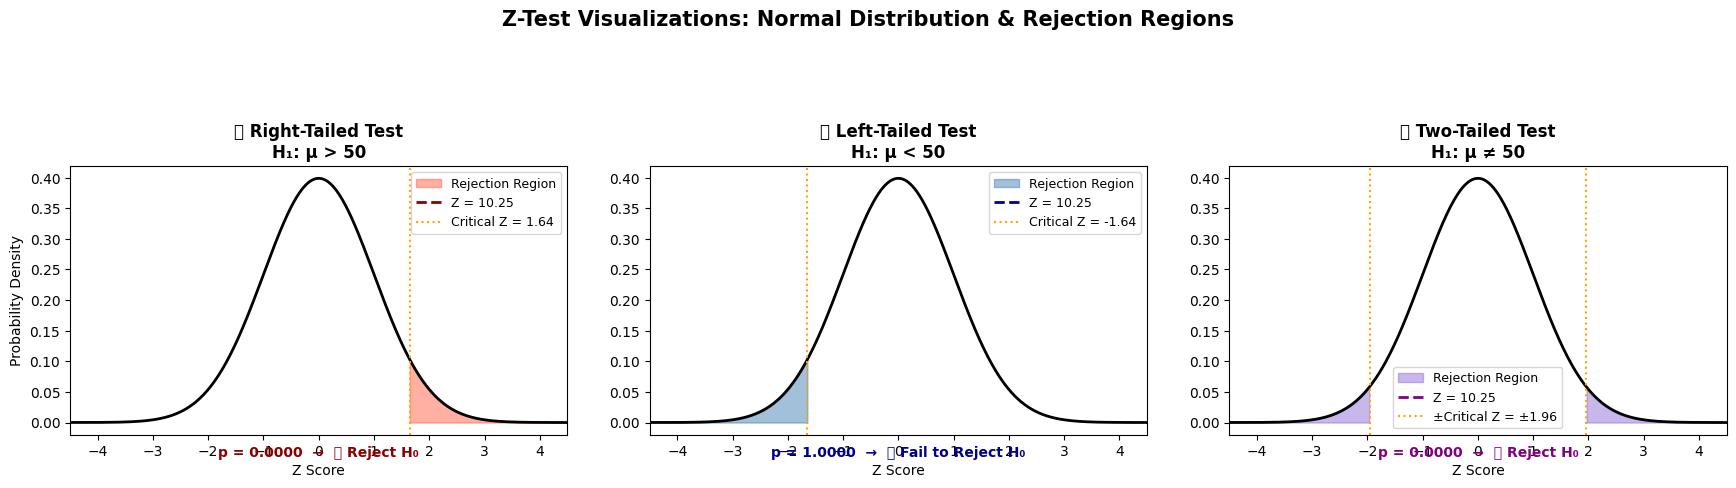


📌 Red/Blue/Purple shaded area = Rejection region | Dashed line = Our Z-score


In [7]:
x = np.linspace(-5, 5, 1000)
y = norm.pdf(x)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Z-Test Visualizations: Normal Distribution & Rejection Regions",
             fontsize=15, fontweight='bold', y=1.02)

critical_z = norm.ppf(1 - alpha)  # 1.645

# ─────────────────────────────────────
# Plot 1: Right-Tailed
# ─────────────────────────────────────
ax1 = axes[0]
ax1.plot(x, y, color='black', linewidth=2)
ax1.fill_between(x, y, where=(x >= critical_z), color='tomato', alpha=0.5, label='Rejection Region')
ax1.axvline(z_stat_right, color='darkred', linewidth=2, linestyle='--', label=f'Z = {z_stat_right:.2f}')
ax1.axvline(critical_z, color='orange', linewidth=1.5, linestyle=':', label=f'Critical Z = {critical_z:.2f}')
ax1.set_title("🔴 Right-Tailed Test\nH₁: μ > 50", fontsize=12, fontweight='bold')
ax1.set_xlabel("Z Score")
ax1.set_ylabel("Probability Density")
ax1.legend(fontsize=9)
ax1.set_xlim(-4.5, 4.5)
result1 = "✅ Reject H₀" if p_value_right < alpha else "❌ Fail to Reject H₀"
ax1.text(0, -0.055, f"p = {p_value_right:.4f}  →  {result1}",
         ha='center', fontsize=10, color='darkred', fontweight='bold')

# ─────────────────────────────────────
# Plot 2: Left-Tailed
# ─────────────────────────────────────
ax2 = axes[1]
ax2.plot(x, y, color='black', linewidth=2)
ax2.fill_between(x, y, where=(x <= -critical_z), color='steelblue', alpha=0.5, label='Rejection Region')
ax2.axvline(z_stat_left, color='darkblue', linewidth=2, linestyle='--', label=f'Z = {z_stat_left:.2f}')
ax2.axvline(-critical_z, color='orange', linewidth=1.5, linestyle=':', label=f'Critical Z = {-critical_z:.2f}')
ax2.set_title("🔵 Left-Tailed Test\nH₁: μ < 50", fontsize=12, fontweight='bold')
ax2.set_xlabel("Z Score")
ax2.legend(fontsize=9)
ax2.set_xlim(-4.5, 4.5)
result2 = "✅ Reject H₀" if p_value_left < alpha else "❌ Fail to Reject H₀"
ax2.text(0, -0.055, f"p = {p_value_left:.4f}  →  {result2}",
         ha='center', fontsize=10, color='darkblue', fontweight='bold')

# ─────────────────────────────────────
# Plot 3: Two-Tailed
# ─────────────────────────────────────
critical_z_two = norm.ppf(1 - alpha / 2)  # 1.96
ax3 = axes[2]
ax3.plot(x, y, color='black', linewidth=2)
ax3.fill_between(x, y, where=(x >= critical_z_two), color='mediumpurple', alpha=0.5, label='Rejection Region')
ax3.fill_between(x, y, where=(x <= -critical_z_two), color='mediumpurple', alpha=0.5)
ax3.axvline(z_stat_two, color='purple', linewidth=2, linestyle='--', label=f'Z = {z_stat_two:.2f}')
ax3.axvline(critical_z_two, color='orange', linewidth=1.5, linestyle=':', label=f'±Critical Z = ±{critical_z_two:.2f}')
ax3.axvline(-critical_z_two, color='orange', linewidth=1.5, linestyle=':')
ax3.set_title("🟣 Two-Tailed Test\nH₁: μ ≠ 50", fontsize=12, fontweight='bold')
ax3.set_xlabel("Z Score")
ax3.legend(fontsize=9)
ax3.set_xlim(-4.5, 4.5)
result3 = "✅ Reject H₀" if p_value_two < alpha else "❌ Fail to Reject H₀"
ax3.text(0, -0.055, f"p = {p_value_two:.4f}  →  {result3}",
         ha='center', fontsize=10, color='purple', fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig("z_test_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Red/Blue/Purple shaded area = Rejection region | Dashed line = Our Z-score")

---
## 📋 Cell 11 — Final Summary Table

In [8]:
def decision(p_val, alpha=0.05):
    return "✅ Reject H₀" if p_val < alpha else "❌ Fail to Reject H₀"

summary = pd.DataFrame({
    "Test Type"       : ["Right-Tailed 🔴", "Left-Tailed 🔵", "Two-Tailed 🟣"],
    "H₁ (Alternate)" : ["μ > 50", "μ < 50", "μ ≠ 50"],
    "Z-Statistic"     : [round(z_stat_right, 4), round(z_stat_left, 4), round(z_stat_two, 4)],
    "P-Value"         : [round(p_value_right, 6), round(p_value_left, 6), round(p_value_two, 6)],
    "Decision"        : [decision(p_value_right), decision(p_value_left), decision(p_value_two)]
})

print("\n" + "=" * 75)
print("                    📊 FINAL SUMMARY — Z-TEST RESULTS                   ")
print("=" * 75)
print(f"  Sample Mean      : {df['Marks'].mean():.2f}")
print(f"  Population Mean  : {population_mean}")
print(f"  Sample Size      : {len(df)}")
print(f"  Std Deviation    : {df['Marks'].std():.4f}")
print(f"  Alpha (α)        : {alpha}")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)


                    📊 FINAL SUMMARY — Z-TEST RESULTS                   
  Sample Mean      : 56.53
  Population Mean  : 50
  Sample Size      : 30
  Std Deviation    : 3.4912
  Alpha (α)        : 0.05
     Test Type H₁ (Alternate)  Z-Statistic  P-Value            Decision
Right-Tailed 🔴         μ > 50      10.2499      0.0         ✅ Reject H₀
 Left-Tailed 🔵         μ < 50      10.2499      1.0 ❌ Fail to Reject H₀
  Two-Tailed 🟣         μ ≠ 50      10.2499      0.0         ✅ Reject H₀


---
## 💡 Cell 12 — Key Takeaways & Interview Tips

### ✅ What We Learned:

| Concept | Description |
|---------|-------------|
| **Z-Test Purpose** | Test if sample mean differs from population mean |
| **Right-Tailed** | Tests if mean is **greater** than claimed value |
| **Left-Tailed** | Tests if mean is **less** than claimed value |
| **Two-Tailed** | Tests if mean is **different** (either direction) |
| **P-value < α** | Reject H₀ (statistically significant result) |
| **P-value ≥ α** | Fail to Reject H₀ (not enough evidence) |

---

### 🎤 Interview-Ready Answer:

> *"I performed one-sample Z-tests using Python's `statsmodels` library for right-tailed, left-tailed, and two-tailed tests. The Z-statistic measures how many standard deviations the sample mean is from the population mean. I compared the p-value with the significance level α = 0.05 to make the reject/fail-to-reject decision. In our dataset of 30 students with a mean of 56.7, the right-tailed and two-tailed tests rejected H₀, confirming the mean is significantly greater than 50."*

---

### ⚠️ Common Mistakes to Avoid:

1. **Using Z-test for small samples** (n < 30) → Use T-test instead
2. **Confusing p-value with probability of H₀ being true** → p-value is the probability of observing this result *if* H₀ were true
3. **Rejecting H₀ = proving H₁** → We only say "sufficient evidence", never "prove"
4. **Forgetting to check normality assumption** for small samples

---
### 🚀 Next Steps:
- **T-Test** → When sample size < 30 or population std is unknown
- **Chi-Square Test** → For categorical data
- **ANOVA** → Comparing means of 3 or more groups